# Customer Churn Prediction — Telco Dataset

Modelo de predicción de abandono de clientes para una empresa de telecomunicaciones. El objetivo es identificar clientes con alta probabilidad de cancelar su servicio.

**Enfoque:**
- Pipeline de ML completo sin data leakage
- Comparación de 3 modelos (Logistic Regression, Random Forest, XGBoost)
- Evaluación con F1-Score como métrica principal (dataset desbalanceado)
- Análisis de errores y feature importance para insights de negocio

**Dataset:** [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7043 clientes, 20 features

**Autor:** Matias Marro  
**Repo:** [github.com/MatiasMarro/Deep-Learning](https://github.com/MatiasMarro/Deep-Learning)

## Setup

In [1]:
!pip install xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, RocCurveDisplay,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42

## 1. Carga y exploración de datos

In [2]:
url = 'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
df = pd.read_csv(url)
print(f'Dataset: {df.shape[0]} clientes, {df.shape[1]} columnas')
df.head()

Dataset: 7043 clientes, 21 columnas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Distribución del target — hay desbalance (73% no churn vs 27% churn)
churn_dist = df['Churn'].value_counts(normalize=True)
print(f'No Churn: {churn_dist["No"]:.1%}')
print(f'Churn:    {churn_dist["Yes"]:.1%}')

No Churn: 73.5%
Churn:    26.5%


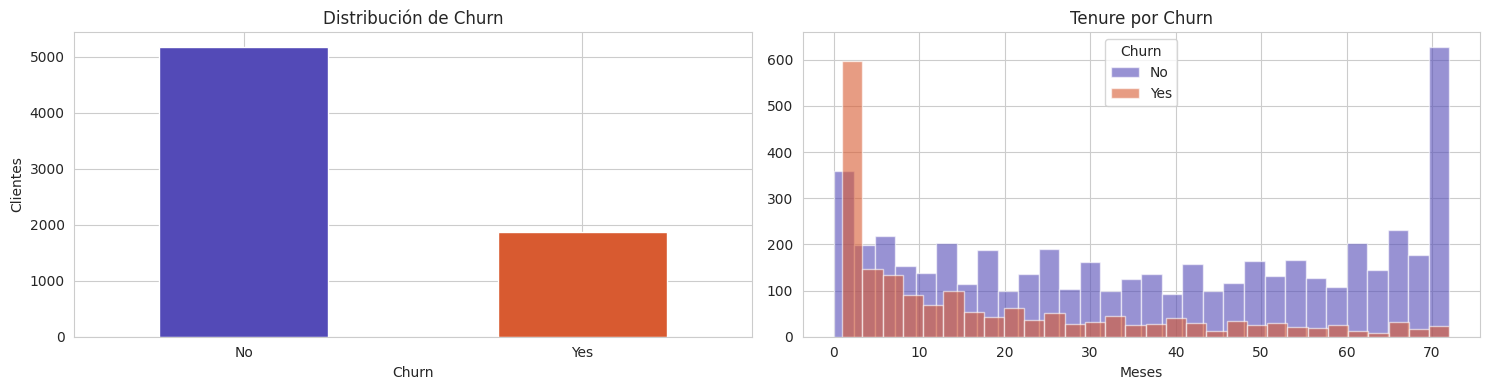

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Target distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#534AB7', '#D85A30'])
axes[0].set_title('Distribución de Churn')
axes[0].set_ylabel('Clientes')
axes[0].tick_params(axis='x', rotation=0)

# Tenure by churn
for label, color in [('No', '#534AB7'), ('Yes', '#D85A30')]:
    df[df['Churn'] == label]['tenure'].hist(alpha=0.6, bins=30, ax=axes[1], color=color, label=label)
axes[1].set_title('Tenure por Churn')
axes[1].set_xlabel('Meses')
axes[1].legend(title='Churn')

plt.tight_layout()
plt.show()

**Observaciones del EDA:**
- Dataset desbalanceado (~27% churn). Accuracy no sirve como métrica principal → uso F1.
- Los clientes con bajo tenure (nuevos) tienen mayor tasa de churn.
- Los clientes con cargos mensuales altos tienden a cancelar más.
- `TotalCharges` aparece como `object` cuando debería ser numérica → hay valores `" "` que hay que limpiar.

## 2. Limpieza de datos

In [9]:
# TotalCharges tiene 11 valores con " " (string vacío). Los convierto a NaN.
print(f'Valores problemáticos en TotalCharges: {(df["TotalCharges"] == " ").sum()}')

df = df.drop('customerID', axis=1)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'Nulos en TotalCharges tras conversión: {df["TotalCharges"].isnull().sum()}')
print(f'Shape: {df.shape}')

Valores problemáticos en TotalCharges: 11
Nulos en TotalCharges tras conversión: 11
Shape: (7043, 20)


## 3. Split train/test

In [10]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Verifico que stratify mantuvo la proporción
print(f'Train: {X_train.shape[0]} filas — churn rate: {y_train.mean():.3f}')
print(f'Test:  {X_test.shape[0]} filas — churn rate: {y_test.mean():.3f}')

Train: 5634 filas — churn rate: 0.265
Test:  1409 filas — churn rate: 0.265


## 4. Pipeline de preprocesamiento

In [11]:
# Derivo las columnas del train set (no del dataset completo)
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Numéricas ({len(num_features)}): {num_features}')
print(f'Categóricas ({len(cat_features)}): {cat_features}')

# Pipelines de preprocesamiento
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, num_features),
    ('cat', categorical_pipe, cat_features)
])

Numéricas (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categóricas (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 5. Entrenamiento y comparación de modelos

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='logloss', random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

print(f'{"Modelo":<25} {"F1 Mean":>10} {"F1 Std":>10}')
print('-' * 47)

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    results[name] = {'pipeline': pipeline, 'scores': scores}
    print(f'{name:<25} {scores.mean():>10.3f} {scores.std():>10.3f}')

Modelo                       F1 Mean     F1 Std
-----------------------------------------------
Logistic Regression            0.592      0.030
Random Forest                  0.541      0.028
XGBoost                        0.555      0.020


## 6. Evaluación del mejor modelo en test

In [15]:
# Selecciono el modelo con mejor F1 promedio en cross-validation
best_name = max(results, key=lambda k: results[k]['scores'].mean())
best_pipeline = results[best_name]['pipeline']
best_scores = results[best_name]['scores']

print(f'Modelo seleccionado: {best_name}')
print(f'F1 en CV: {best_scores.mean():.3f} ± {best_scores.std():.3f}')

Modelo seleccionado: Logistic Regression
F1 en CV: 0.592 ± 0.030


In [16]:
# Entreno en todo el train set y evalúo en test
best_pipeline.fit(X_train, y_train)

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))
print(f'AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}')

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

AUC-ROC: 0.842


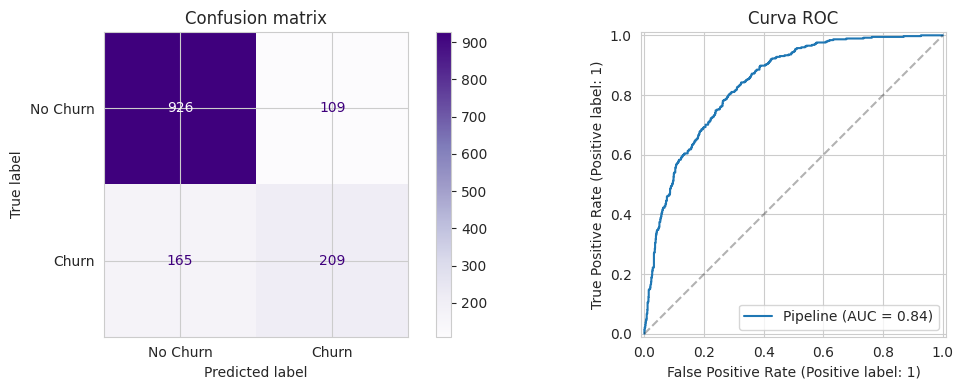

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['No Churn', 'Churn'],
    cmap='Purples', ax=axes[0]
)
axes[0].set_title('Confusion matrix')

# ROC curve
RocCurveDisplay.from_estimator(best_pipeline, X_test, y_test, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('Curva ROC')

plt.tight_layout()
plt.show()

## 7. Feature importance

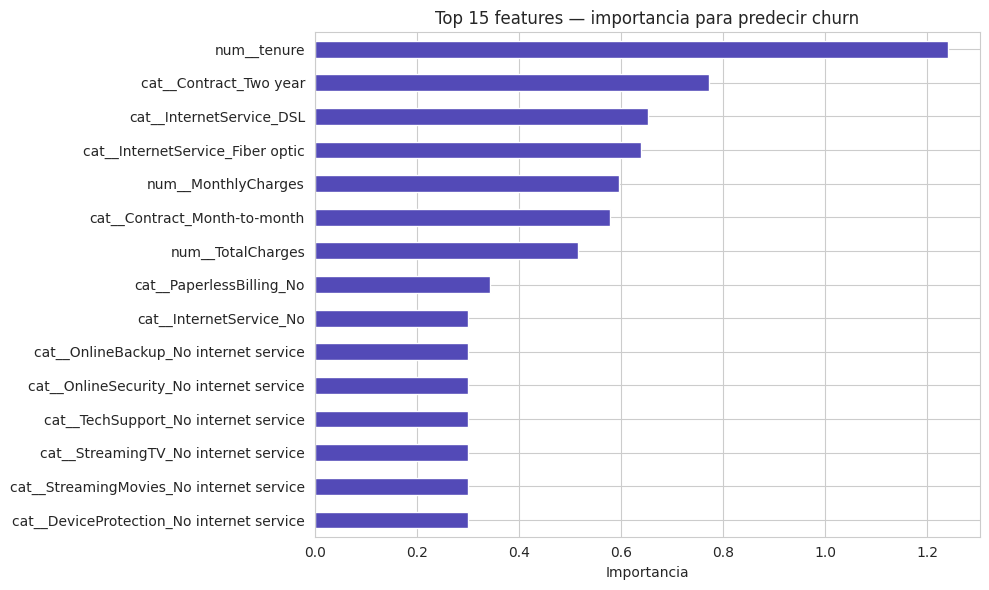

In [18]:
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Logistic Regression usa coef_, tree-based usan feature_importances_
classifier = best_pipeline.named_steps['classifier']
if hasattr(classifier, 'coef_'):
    importances = np.abs(classifier.coef_[0])
else:
    importances = classifier.feature_importances_

feat_imp = pd.Series(importances, index=feature_names)

plt.figure(figsize=(10, 6))
feat_imp.nlargest(15).sort_values().plot(kind='barh', color='#534AB7')
plt.title('Top 15 features — importancia para predecir churn')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

## 8. Análisis de errores

In [19]:
# ¿Qué tipo de clientes se le escapan al modelo? (falsos negativos)
fn_mask = (y_test == 1) & (y_pred == 0)
tp_mask = (y_test == 1) & (y_pred == 1)

print(f'Churns detectados (TP): {tp_mask.sum()}')
print(f'Churns no detectados (FN): {fn_mask.sum()}')
print(f'Recall: {tp_mask.sum() / (tp_mask.sum() + fn_mask.sum()):.2%}')

comparison = pd.DataFrame({
    'Churn detectado (TP)': X_test[tp_mask][num_features].mean(),
    'Churn no detectado (FN)': X_test[fn_mask][num_features].mean()
}).round(2)

print('\nComparación de características promedio:')
comparison

Churns detectados (TP): 209
Churns no detectados (FN): 165
Recall: 55.88%

Comparación de características promedio:


,Churn detectado (TP),Churn no detectado (FN)
SeniorCitizen,0.31,0.20
tenure,9.92,24.75
MonthlyCharges,78.64,65.32
TotalCharges,867.04,2076.70


## Conclusiones

- El mejor modelo fue **Logistic Regression** con F1 = 0.59 en cross-validation, superando a Random Forest y XGBoost en este dataset.
- Los **factores principales** de churn son el tipo de contrato (mes a mes), tenure bajo, cargos mensuales altos y ausencia de servicios como soporte técnico.
- Los clientes que el modelo falla en detectar (falsos negativos) tienden a tener **mayor antigüedad** — son clientes establecidos que cancelan por razones menos predecibles.